# L1 · Why these losses? Gaussian NLL **is** MSE

**One idea:** choosing a loss = choosing a probabilistic noise model.
If we assume Gaussian observation noise, the negative log-likelihood (NLL)
of the data is the squared error *up to constants* — so minimizing MSE
**is** maximum likelihood. Different noise models give different losses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1. MSE and Gaussian NLL share the same minimizer

For $y_i \sim \mathcal N(\mu,\sigma^2)$,
$-\log p(y_i\mid\mu) = \frac{(y_i-\mu)^2}{2\sigma^2} + \tfrac12\log(2\pi\sigma^2)$.
Only the first term depends on $\mu$, so $\arg\min_\mu \text{NLL} = \arg\min_\mu \text{MSE}$.

In [2]:
mu_true, sigma = 4.0, 1.5
y = np.random.normal(mu_true, sigma, size=200)

def gaussian_nll(mu, y, sigma):
    return np.sum(0.5*(y-mu)**2/sigma**2 + 0.5*np.log(2*np.pi*sigma**2))

def mse(mu, y):
    return np.mean((y-mu)**2)

mus  = np.linspace(2, 6, 800)
nll  = np.array([gaussian_nll(m, y, sigma) for m in mus])
mses = np.array([mse(m, y) for m in mus])

print("argmin NLL  mu =", round(mus[nll.argmin()], 4))
print("argmin MSE  mu =", round(mus[mses.argmin()], 4))
print("sample mean    =", round(y.mean(), 4))

argmin NLL  mu = 4.1076
argmin MSE  mu = 4.1076
sample mean    = 4.1064


## 2. Different noise density $\Rightarrow$ different loss $-\log p(r)$

Gaussian noise gives a squared loss $r^2$; Laplace noise gives $|r|$ (robust to outliers).

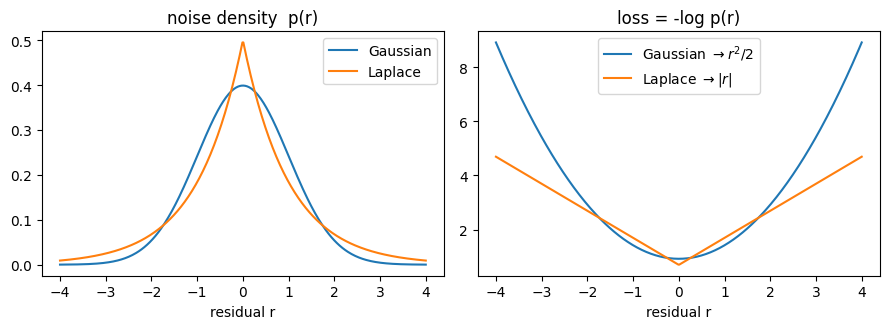

In [3]:
r = np.linspace(-4, 4, 400)
b = 1.0
gauss_p = np.exp(-r**2/2)/np.sqrt(2*np.pi)
lap_p   = np.exp(-np.abs(r)/b)/(2*b)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(r, gauss_p, label="Gaussian"); ax[0].plot(r, lap_p, label="Laplace")
ax[0].set_title("noise density  p(r)"); ax[0].set_xlabel("residual r"); ax[0].legend()
ax[1].plot(r, -np.log(gauss_p), label=r"Gaussian $\to r^2/2$")
ax[1].plot(r, -np.log(lap_p),   label=r"Laplace $\to |r|$")
ax[1].set_title("loss = -log p(r)"); ax[1].set_xlabel("residual r"); ax[1].legend()
plt.tight_layout(); plt.show()

## Takeaway
- **Gaussian likelihood $\Rightarrow$ MSE.** The two objectives have identical minimizers.
- The *shape* of the assumed noise density is the *shape* of the loss:
  square for Gaussian, absolute value (robust) for Laplace.
- When you meet a loss, ask **"what likelihood produced it?"**